In [167]:
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")

In [168]:
data = open('names.txt', 'r').read().splitlines()

In [169]:
clean = sorted(list(set(''.join(data))))

In [170]:
char_to_int = {s:i+1 for i, s in enumerate(clean)}

char_to_int['.'] = 0
int_to_char = {i:s for s, i in char_to_int.items()}

In [202]:
block_size = 8
x, y = [], []
for datum in data[:5]:
    print(datum)
    context = [0] * block_size
    for ch in datum + '.':
        ix = char_to_int[ch]
        x.append(context)
        y.append(ix)
        print("".join(int_to_char[i] for i in context), '----->', int_to_char[ix])
        context = context[1:] +  [ix]

emma
........ -----> e
.......e -----> m
......em -----> m
.....emm -----> a
....emma -----> .
olivia
........ -----> o
.......o -----> l
......ol -----> i
.....oli -----> v
....oliv -----> i
...olivi -----> a
..olivia -----> .
ava
........ -----> a
.......a -----> v
......av -----> a
.....ava -----> .
isabella
........ -----> i
.......i -----> s
......is -----> a
.....isa -----> b
....isab -----> e
...isabe -----> l
..isabel -----> l
.isabell -----> a
isabella -----> .
sophia
........ -----> s
.......s -----> o
......so -----> p
.....sop -----> h
....soph -----> i
...sophi -----> a
..sophia -----> .


In [203]:
x = torch.tensor(x)
y = torch.tensor(y)
g = torch.Generator().manual_seed(213456789)
w1 = torch.randn((6, 100), generator = g)
b1  = torch.randn(100, generator = g)
w2 = torch.randn((100, 27), generator = g)
b2 = torch.randn(27, generator = g)
c = torch.rand((27,2), generator = g)
parameters = [c, w1, b1, w2, b2]

In [204]:
for p in parameters:
    p.requires_grad = True

In [205]:
lre = torch.linspace(-3, 0, 1000)
lrs = 10 ** lre

In [207]:
lri = []
lossi = []
for i in range(1000):
    ix = torch.randint(0, x.shape[0], (32,))
    emb = c[x[ix]]
    h = torch.tanh(new @ w1 + b1)
    new = emb.view(emb.shape[0], 6)
    logit = h @ w2 + b2
    loss = F.cross_entropy(logit, y)
    print(loss.item())
    
    for p in parameters:
        p.grad = None
    loss.backward()
    
    lr = lrs[i]

    for p in parameters:
        p.data += -lr * p.grad
    lossi.append(loss.item())
    lri.append(lr)

RuntimeError: shape '[32, 6]' is invalid for input of size 512

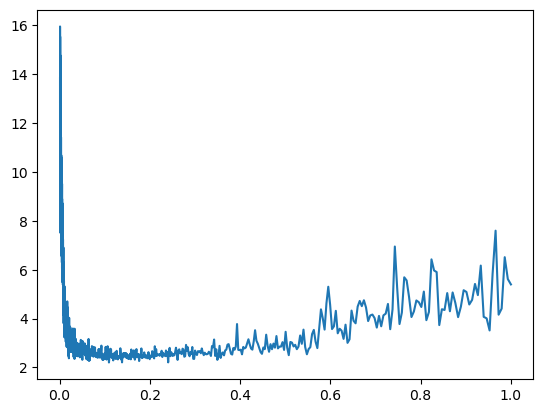

In [201]:
plt.plot(lri, lossi);